**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('/content/bank.csv')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
df.shape

(11162, 17)

**Dataset Information**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [6]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


**Check Missing Values**

In [7]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# Remove, if present
df.drop_duplicates(inplace=True)

**Exploratory Data Analysis (EDA): Target Variable Distribution**

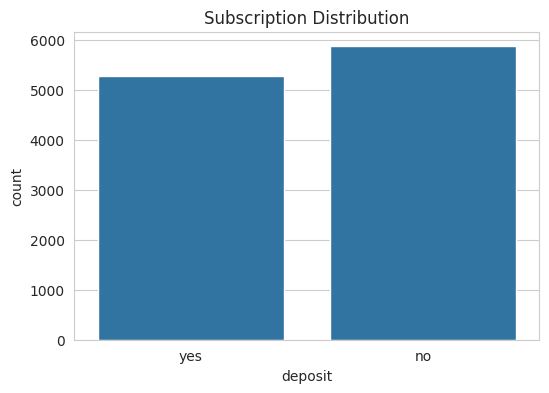

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='deposit',
    data=df
)

plt.title("Subscription Distribution")
plt.show()

**Age Distribution**

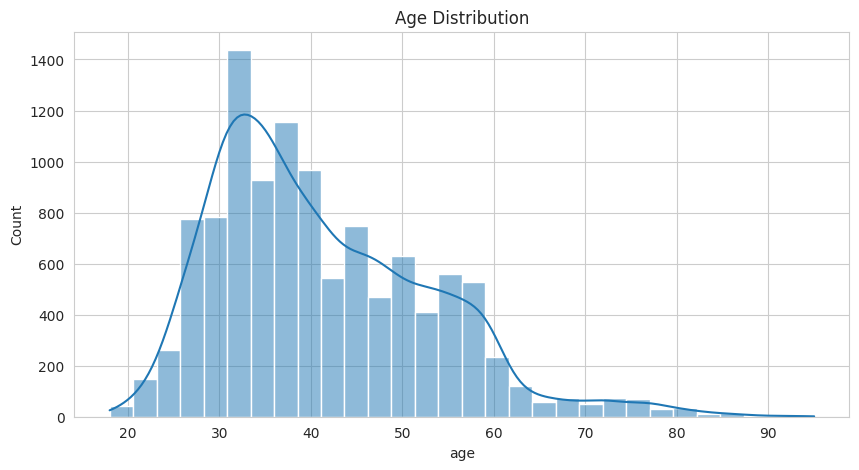

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

**Job Distribution**

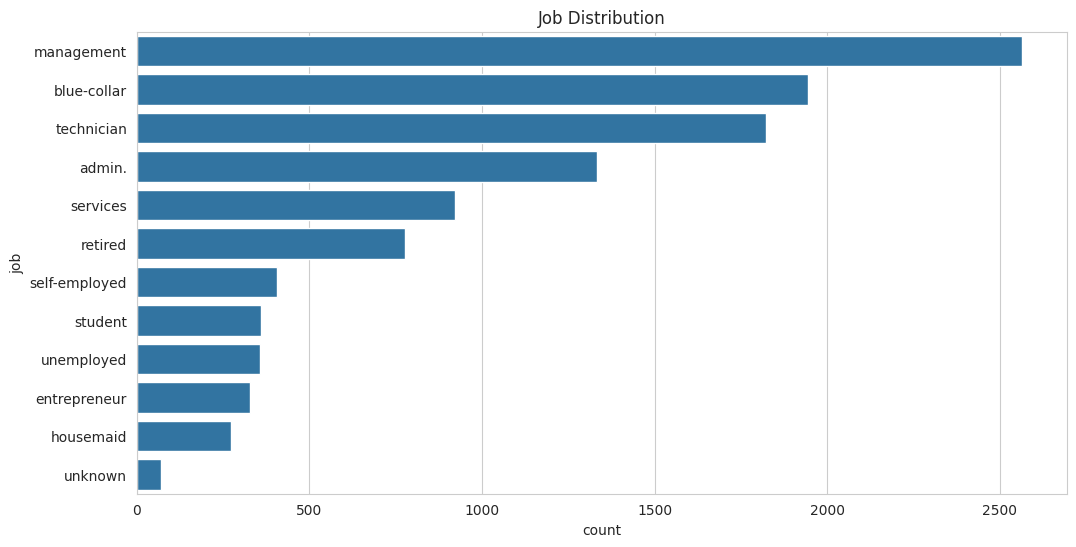

In [13]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='job',
    data=df,
    order=df['job'].value_counts().index
)

plt.title("Job Distribution")
plt.show()

**Marital Status**

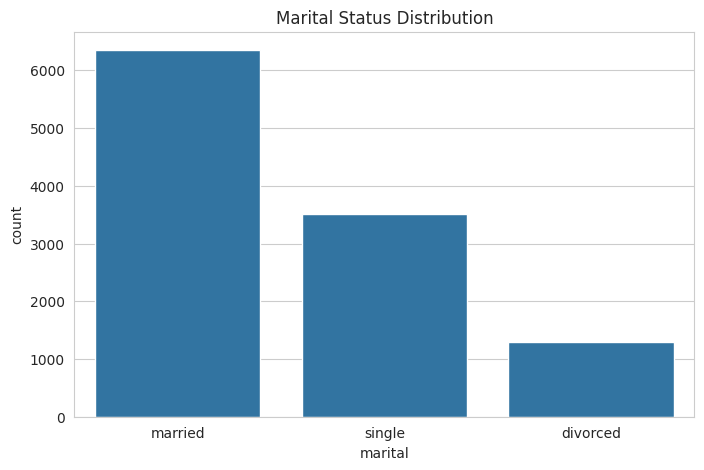

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='marital',
    data=df
)

plt.title("Marital Status Distribution")
plt.show()

**Subscription by Job**

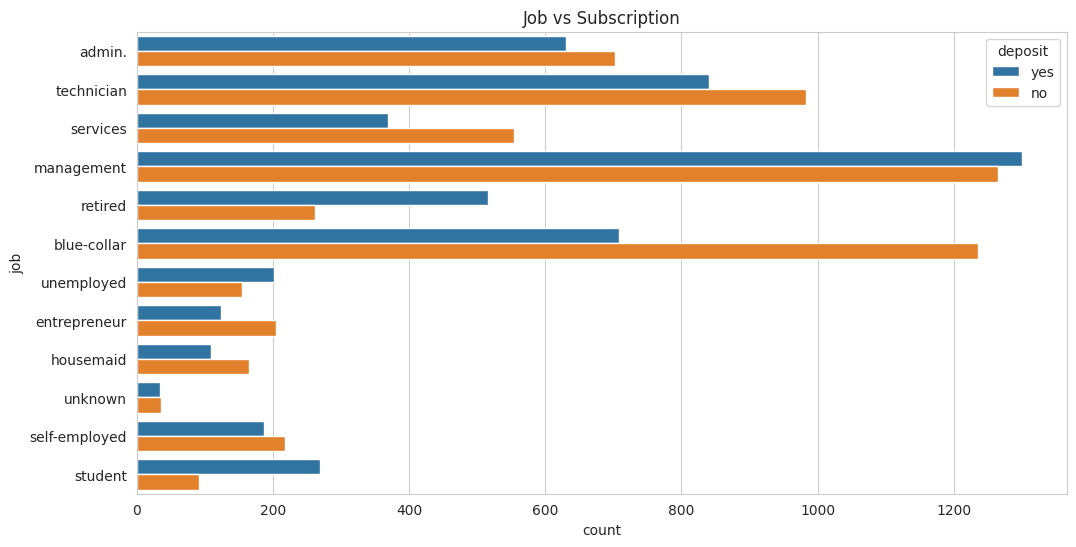

In [16]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='job',
    hue='deposit',
    data=df
)

plt.title("Job vs Subscription")
plt.show()

**Encode Categorical Variables**

In [17]:
le = LabelEncoder()

In [18]:
for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(df[col])

**Correlation Heatmap**

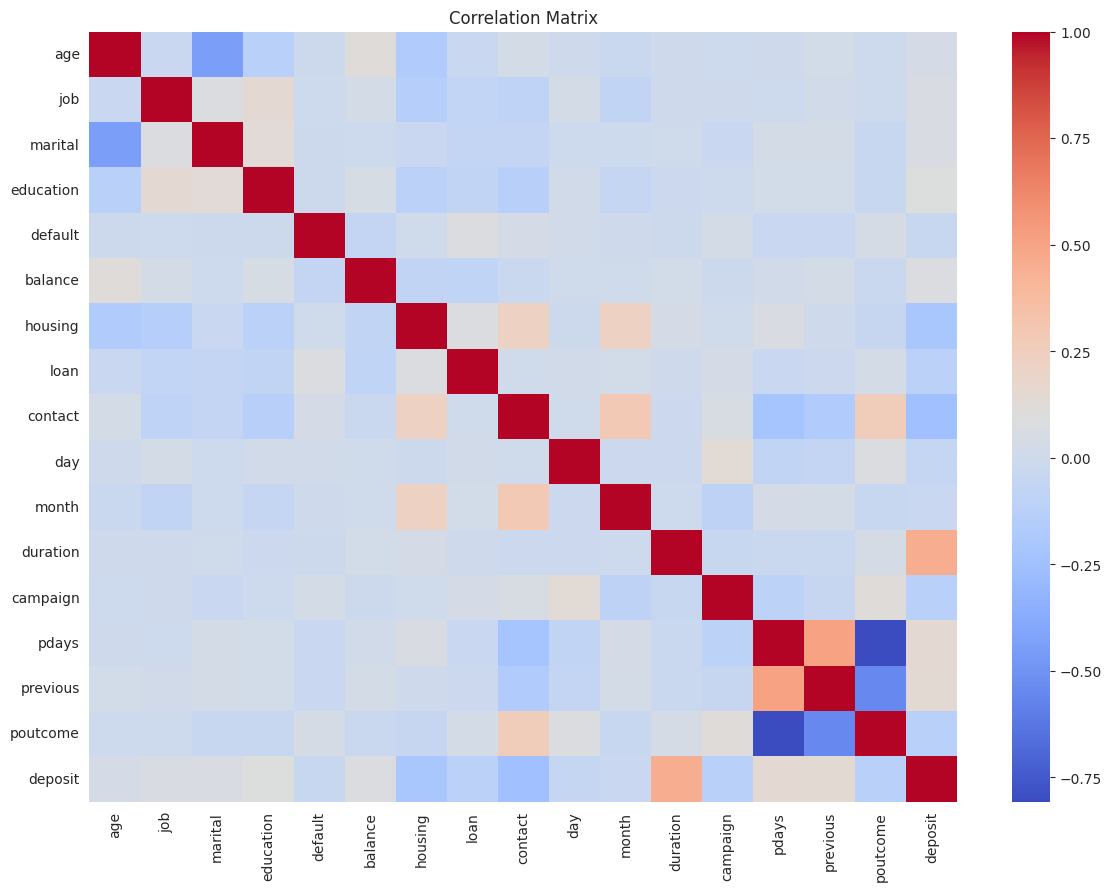

In [19]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

**Feature Selection**

In [21]:
X = df.drop('deposit', axis=1)

y = df['deposit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Train Decision Tree Model**

In [23]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [24]:
y_pred = model.predict(X_test) # Prediction

accuracy = accuracy_score(y_test, y_pred) # Accuracy Score

print("Accuracy:", accuracy)

Accuracy: 0.7630989699955217


**Confusion Matrix**

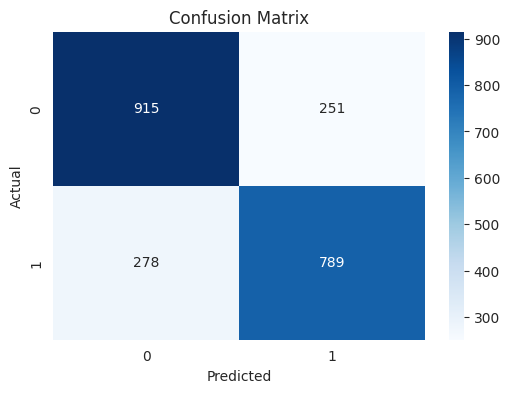

In [25]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Classification Report**

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.78      0.78      1166
           1       0.76      0.74      0.75      1067

    accuracy                           0.76      2233
   macro avg       0.76      0.76      0.76      2233
weighted avg       0.76      0.76      0.76      2233



**Feature Importance**

In [29]:
importance = pd.DataFrame({'Feature':X.columns, 'Importance':model.feature_importances_})

In [30]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

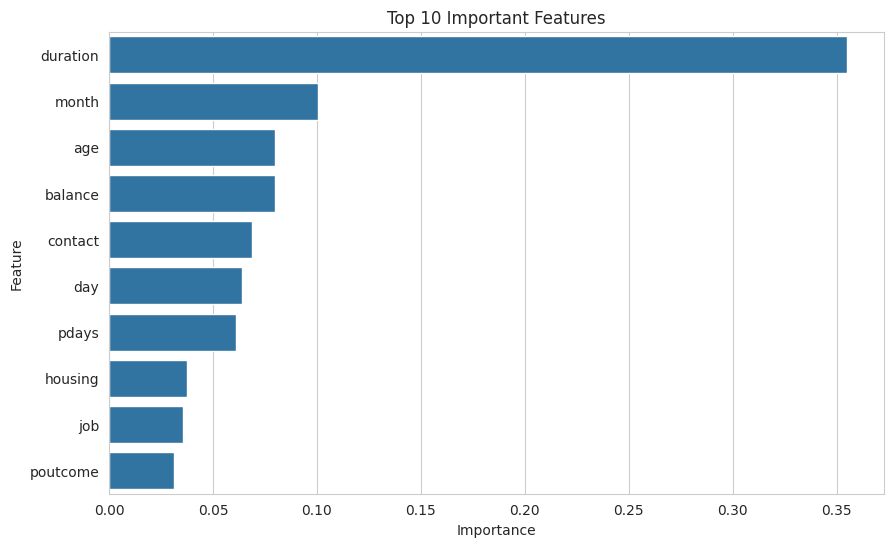

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

**Visualize Decision Tree**

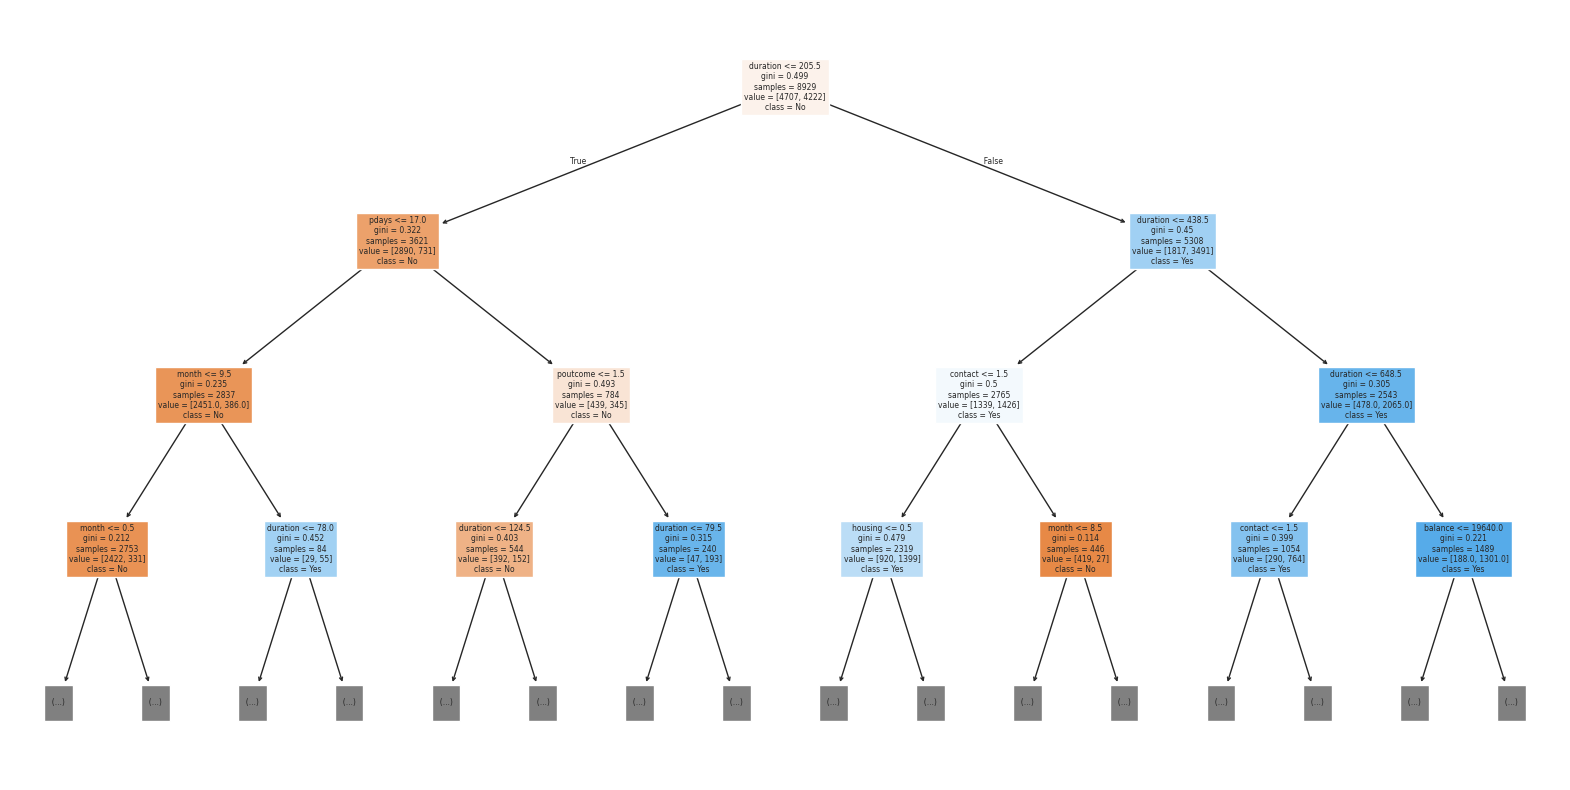

In [32]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=['No','Yes'],
    max_depth=3
)

plt.show()

_____________________________
**Key Findings**
1. Most customers did not subscribe to the term deposit.

2. Age and occupation influence customer behavior.

3. Previous campaign information plays a significant role.

4. Decision Tree effectively classifies customer subscription outcomes.

5. Certain features contribute more strongly to prediction accuracy.

Conclusion

The Decision Tree Classifier was successfully developed to predict customer subscription behavior. After preprocessing and encoding the dataset, the model achieved good classification performance. Feature importance analysis revealed the most influential factors affecting customer decisions. The project demonstrates the practical application of machine learning in customer behavior prediction.